In [105]:
import pyart
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import cartopy.crs as ccrs
from pyproj import Proj, CRS, Transformer
import glob
import xarray as xr
from datetime import datetime, timedelta
import pandas as pd
from scipy.interpolate import griddata
from collections import defaultdict
from scipy.spatial import KDTree
import os
from sklearn.neighbors import KNeighborsRegressor

In [31]:
# Program Inputs for which day in question
year = '2025'
month = '03'
day = '13'

# Important parameters
a = 18 
aHigh = 43
aLow = 11
b = 1.1

theta = 18
 



In [9]:
# Access directories
scanningDir = '/gws/nopw/j04/tone_ico_gws/data/tone-ico_doppler_scanning_cloud_radar/L0/Y'+year+'/M'+month+'/D'+day+'/*el_18*PPI.LV1.NC'
scanningFiles = sorted(glob.glob(scanningDir))  

vertDir = '/gws/nopw/j04/tone_ico_gws/cloudnet/troll/radar/'
vertFiles = sorted(glob.glob('/gws/nopw/j04/tone_ico_gws/cloudnet/troll/radar/2025*.nc')) 

In [24]:
# Takes in the raw data and a target grid, extracts reflectivity and regrids to the target grid
def extractFields(ds, lat_target, lon_target):
    # === Extract reflectivity ===
    cze_vars = ['C1ZE45', 'C2ZE45', 'C3ZE45', 'C4ZE45']
    range_vars = [var.replace('ZE45', 'Range') for var in cze_vars]
    data_list = [ds[var].values for var in cze_vars]
    range_list = [ds[var].values for var in range_vars]

    # Stack reflectivity and range
    data_stacked = np.concatenate(data_list, axis=1)  # (n_az, total_range)
    ranges_stacked = np.concatenate(range_list)       # (total_range,)

    # Filter low reflectivity
    data_stacked[data_stacked < -30] = np.nan

    # === Get azimuths ===
    n_az = data_stacked.shape[0]
    azimuths = np.linspace(0, 2 * np.pi, n_az, endpoint=False)

    azimuths_2d, ranges_2d = np.meshgrid(azimuths, ranges_stacked, indexing='ij')
    X = ranges_2d * np.cos(azimuths_2d)
    Y = ranges_2d * np.sin(azimuths_2d)

    # === Polar to lat/lon ===
    trollLat = ds['GPSLat'].values.item()
    trollLon = ds['GPSLon'].values.item()
    crs_centered = CRS.from_proj4(f"+proj=aeqd +lat_0={trollLat} +lon_0={trollLon} +datum=WGS84 +units=m +no_defs")
    crs_geo = CRS.from_epsg(4326)
    transformer = Transformer.from_crs(crs_centered, crs_geo, always_xy=True)
    lon, lat = transformer.transform(X, Y)

    # === Interpolate reflectivity onto target grid ===
    points = np.column_stack((lat.ravel(), lon.ravel()))
    values = data_stacked.ravel()
    dbz_interp = griddata(points, values, (lat_target, lon_target), method='linear', fill_value=np.nan)

    # === Interpolate time onto target grid ===
    # Time is in seconds since 2001-01-01 00:00:00
    time_array = ds['Time'].values.astype(float)  # shape: (n_az,)
    base = np.datetime64('2001-01-01T00:00:00', 's')

    # Convert to datetime and then seconds since midnight
    absolute_times = base + time_array.astype('timedelta64[s]')
    seconds_since_midnight = (absolute_times - absolute_times.astype('datetime64[D]')).astype('timedelta64[s]').astype(float)

    # Expand time to match (n_az, n_range)
    time_2d = np.repeat(seconds_since_midnight[:, np.newaxis], data_stacked.shape[1], axis=1)

    # Interpolate time field onto the same target grid
    time_values = time_2d.ravel()
    time_interp = griddata(points, time_values, (lat_target, lon_target), method='linear', fill_value=np.nan)

    rangeVals = ranges_2d.ravel()
    range_interp = griddata(points, rangeVals, (lat_target, lon_target), method='linear', fill_value=np.nan)


    return dbz_interp, time_interp, range_interp

In [5]:
# converts dbz to snowfall rate - ADJUST A, B (Souverijns et al. 2017) as needed
def zToSR(dbz, a, b):
    dbz[dbz > 1000] = np.nan
    #z = 10 ** (dbz / 10)

    rate = (dbz / a) ** (1 / b)
    return rate

In [7]:
# Returns forward, central, and backward difference-based averages of a 2D array, for numerical integration
def weightedAvg(y):
    y = np.asarray(y)
    nx, ny, nt = y.shape
    avg = np.full_like(y, np.nan, dtype=np.float64)

    # Forward difference at index 0
    y0 = y[:, :, 0]
    y1 = y[:, :, 1]
    weights = (~np.isnan(y0)).astype(float) * 2 + (~np.isnan(y1)).astype(float)
    vals = np.nan_to_num(y0) * 2 + np.nan_to_num(y1)
    avg[:, :, 0] = np.where(weights > 0, vals / weights, np.nan)

    # Central differences
    for i in range(1, nt - 1):
        ym = y[:, :, i - 1]
        yc = y[:, :, i]
        yp = y[:, :, i + 1]

        weights = (
            (~np.isnan(ym)).astype(float) +
            2 * (~np.isnan(yc)).astype(float) +
            (~np.isnan(yp)).astype(float)
        )
        vals = (
            np.nan_to_num(ym) +
            2 * np.nan_to_num(yc) +
            np.nan_to_num(yp)
        )
        avg[:, :, i] = np.where(weights > 0, vals / weights, np.nan)

    # Backward difference at index -1
    y_1 = y[:, :, -1]
    y_2 = y[:, :, -2]
    weights = (~np.isnan(y_2)).astype(float) + 2 * (~np.isnan(y_1)).astype(float)
    vals = np.nan_to_num(y_2) + 2 * np.nan_to_num(y_1)
    avg[:, :, -1] = np.where(weights > 0, vals / weights, np.nan)

    return avg

In [11]:
def nativeExtract(ds):
    # === Extract reflectivity ===
    cze_vars = ['C1ZE45', 'C2ZE45', 'C3ZE45', 'C4ZE45']
    range_vars = [var.replace('ZE45', 'Range') for var in cze_vars]
    data_list = [ds[var].values for var in cze_vars]
    range_list = [ds[var].values for var in range_vars]

    # Stack reflectivity and range
    data_stacked = np.concatenate(data_list, axis=1)  # (n_az, total_range)
    ranges_stacked = np.concatenate(range_list)       # (total_range,)

    # Filter low reflectivity
    data_stacked[data_stacked < -30] = np.nan

    # === Get azimuths ===
    n_az = data_stacked.shape[0]
    azimuths = np.linspace(0, 2 * np.pi, n_az, endpoint=False)
    azimuths_2d, ranges_2d = np.meshgrid(azimuths, ranges_stacked, indexing='ij')

    return azimuths_2d, ranges_2d, data_stacked

In [10]:
# generating the target uniform lat/lon grid
lat_grid = np.arange(-72.15, -71.85, 0.001)
lon_grid = np.arange(2, 3, 0.001)
lon_target, lat_target = np.meshgrid(lon_grid, lat_grid)
nlon, nlat = len(lon_grid), len(lat_grid)



In [115]:
# First extract the vertical profile data for date in question
date_prefix = f"{year}{month}{day}"
matching_files = [f for f in vertFiles if f.startswith(vertDir + date_prefix)]
vertDay = matching_files[0]
vertDs = nc.Dataset(vertDay)

dbzVert_base = np.array(vertDs.variables['Zh'])
timeVert = np.array(vertDs.variables['time'])
vertProfile = np.array(vertDs.variables['range'])
dbzVert_base[dbzVert_base > 1000] = np.nan

hour_bins = np.floor(timeVert).astype(int)

# Temporal averaging for each hour, for the vertical profile
nspace = dbzVert_base.shape[1]
dbzVert = np.full((24, nspace), np.nan)  # use NaNs in case some hours are missing

for hour in range(24):
    idx = hour_bins == hour
    if np.any(idx):
        dbzVert[hour] = np.nanmean(dbzVert_base[idx], axis=0)

baseDbz = dbzVert[:, 0]
bigDbz = np.tile(baseDbz[:, np.newaxis], (1, 710))
vertCorrection = bigDbz - dbzVert
vertCorrect_fill = np.zeros_like(vertCorrection)

# Creating a vertical profile that will give you the elevation correction for a given elevation
for i in range(24):
    mask = ~np.isnan(vertCorrection[i])
    vertHour = vertCorrection[i]
    known = vertHour[mask]

    # Create vertical profile using nearest neighbors regression
    knr = KNeighborsRegressor(n_neighbors=5)
    knr.fit(vertProfile[mask].reshape(-1, 1), known)
    vertCorr_pred = knr.predict(vertProfile[np.isnan(vertHour)].reshape(-1, 1))

    vertTemp = vertHour.copy()
    vertTemp[np.isnan(vertHour)] = vertCorr_pred
    vertCorrect_fill[i] = vertTemp


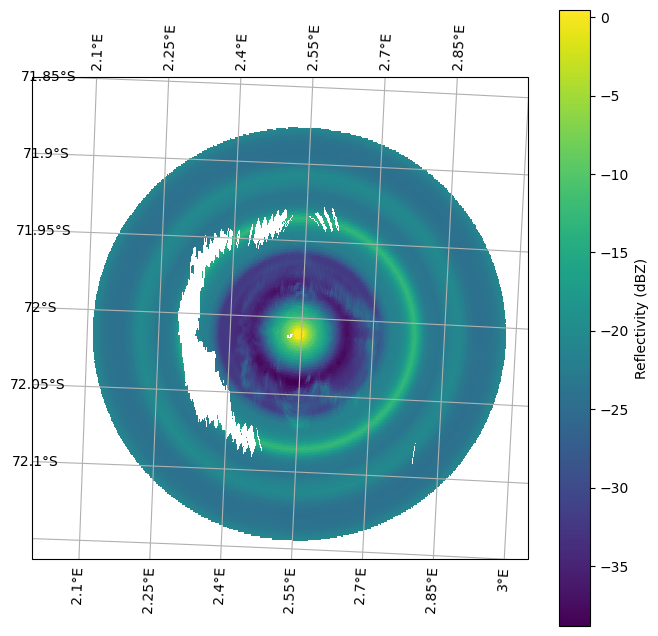

In [103]:
# Data processing for the 2D scanning radar
nativeAzimuths = []
nativeRanges = []
nativeSnow = []

timesteps = len(scanningFiles)
timeGrid = np.empty((nlat, nlon, timesteps))
dbzGrid = np.empty((nlat, nlon, timesteps))
elvGrid = np.empty((nlat, nlon, timesteps))
snowGridMid = np.empty((nlat, nlon, timesteps))
snowGridHigh = np.empty((nlat, nlon, timesteps))
snowGridLow = np.empty((nlat, nlon, timesteps))


# iterating over all the hourly radar scans during the given day, and storing in a common data structure on a common grid
k = 18
for file in scanningFiles[18:19]:
    ds = xr.open_dataset(file)


    # Step 1: Extract reflectivity and time on both native and common resolutions
    natAzimuths, natRanges, natDbz = nativeExtract(ds)
    dbz_interp, time_interp, range_interp = extractFields(ds, lat_target, lon_target)
    elv_interp = range_interp * np.sin(np.deg2rad(theta))  

    # Apply elevation correction

    # First find index of closest vertical profile elevation for each interpolated elevation
    elv_flat = elv_interp.ravel()
    flatClosest = np.full(elv_flat.shape, fill_value=-1, dtype=int)
    valid_mask = ~np.isnan(elv_flat)
    valid_values = elv_flat[valid_mask]

    idxs = np.searchsorted(vertProfile, valid_values)
    idxs_left = np.clip(idxs - 1, 0, len(vertProfile) - 1)
    idxs_right = np.clip(idxs, 0, len(vertProfile) - 1)
    dist_left = np.abs(valid_values - vertProfile[idxs_left])
    dist_right = np.abs(valid_values - vertProfile[idxs_right])
    closest_flat = np.where(dist_left <= dist_right, idxs_left, idxs_right)
    flatClosest[valid_mask] = closest_flat
    closestIndices = flatClosest.reshape(elv_interp.shape)


    # Apply the correction
    correctionGrid = np.zeros([nlat, nlon])
    correctionGrid[:] = np.nan

    for i in range(nlat):
        for j in range(nlon):
            if not np.isnan(elv_interp[i, j]):
                correctionGrid[i, j] = vertCorrection[k, closestIndices[i, j]] 

    dbz_corrected = dbz_interp + correctionGrid


    # Plot
    fig = plt.figure(figsize=(8, 8))

    ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.gridlines(draw_labels=True)
    ax.set_extent([2, 3, -72.15, -71.85], crs=ccrs.PlateCarree())
    ax.coastlines()
    pcm = ax.pcolormesh(lon_target, lat_target, dbz_corrected, transform=ccrs.PlateCarree(), cmap='viridis')
    plt.colorbar(pcm, ax=ax, label='Reflectivity (dBZ)')

    # Step 2: Convert to snowfall rate
    snowfallRateMid = zToSR(dbz_interp, a, b)
    snowfallRateLow = zToSR(dbz_interp, aHigh, b)
    snowfallRateHigh = zToSR(dbz_interp, aLow, b)
    natSnowfall = zToSR(natDbz, a, b)

    # Step 3: Populate the (lat x lon x time) arrays for time, dbz, snowfall rate, and lists of native resolution files
    timeGrid[:, :, k] = time_interp
    dbzGrid[:, :, k] = dbz_interp 
    snowGridMid[:, :, k] = snowfallRateMid
    snowGridHigh[:, :, k] = snowfallRateHigh
    snowGridLow[:, :, k] = snowfallRateLow
    elvGrid[:, :, k] = elv_interp 
    nativeAzimuths.append(natAzimuths)
    nativeRanges.append(natRanges)
    nativeSnow.append(natSnowfall)
    
    k = k + 1

# Sort the arrays by time
sort_indices = np.argsort(timeGrid, axis=2)

timeSort_0313 = np.take_along_axis(timeGrid, sort_indices, axis=2)
dbzSort_0313 = np.take_along_axis(dbzGrid, sort_indices, axis=2)
snowSortMid_0313 = np.take_along_axis(snowGridMid, sort_indices, axis=2)
snowSortHigh_0313 = np.take_along_axis(snowGridHigh, sort_indices, axis=2)
snowSortLow_0313 = np.take_along_axis(snowGridLow, sort_indices, axis=2)
hourlyAccumMid_0313 = weightedAvg(snowSortMid_0313)
hourlyAccumHigh_0313 = weightedAvg(snowSortHigh_0313)
hourlyAccumLow_0313 = weightedAvg(snowSortLow_0313)

In [13]:
# Data processing ERA5

modfile_path = '/gws/nopw/j04/tone_ico_gws/cloudnet/troll/era5/8c77d7d4c6e1d8b637bca6cfa6a85450.nc'
model = nc.Dataset(modfile_path)

fullGrid = np.array(model.variables['mxtpr'][:, :, :]) * 60 * 60
eraLat = np.array(model.variables['latitude'][:]) 
eraLon = np.array(model.variables['longitude'][:]) 